In [109]:
pip install pandas numpy matplotlib seaborn tqdm IPython pyarrow fastparquet

Note: you may need to restart the kernel to use updated packages.


In [110]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm.auto import tqdm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [111]:
#Set some display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

data_path = './dataset/'

# Load the metadata files
print("Loading train.csv (metadata)...")
train_meta = pd.read_csv(data_path + 'train.csv')

print("Loading test.csv (metadata)...")
test_meta = pd.read_csv(data_path + 'test.csv')

print("\n--- Train Metadata ---")
print(f"Shape: {train_meta.shape}")
display(train_meta.head())

print("\n--- Test Metadata ---")
print(f"Shape: {test_meta.shape}")
display(test_meta.head())

Loading train.csv (metadata)...


Loading test.csv (metadata)...

--- Train Metadata ---
Shape: (8789, 38)


,lab_id,video_id,mouse1_strain,mouse1_color,mouse1_sex,mouse1_id,mouse1_age,mouse1_condition,mouse2_strain,mouse2_color,mouse2_sex,mouse2_id,mouse2_age,mouse2_condition,mouse3_strain,mouse3_color,mouse3_sex,mouse3_id,mouse3_age,mouse3_condition,mouse4_strain,mouse4_color,mouse4_sex,mouse4_id,mouse4_age,mouse4_condition,frames_per_second,video_duration_sec,pix_per_cm_approx,video_width_pix,video_height_pix,arena_width_cm,arena_height_cm,arena_shape,arena_type,body_parts_tracked,behaviors_labeled,tracking_method
0,AdaptableSnail,44566106,CD-1 (ICR),white,male,10.0,8-12 weeks,wireless device,CD-1 (ICR),white,male,24.0,8-12 weeks,wireless device,CD-1 (ICR),white,male,38.0,8-12 weeks,wireless device,CD-1 (ICR),white,male,51.0,8-12 weeks,wireless device,30.0,615.6,16.0,1228,1068,60.0,60.0,square,familiar,"[""body_center"", ""ear_left"", ""ear_right"", ""head...","[""mouse1,mouse2,approach"", ""mouse1,mouse2,atta...",DeepLabCut
1,AdaptableSnail,143861384,CD-1 (ICR),white,male,3.0,8-12 weeks,NaN,CD-1 (ICR),white,male,17.0,8-12 weeks,NaN,CD-1 (ICR),white,male,31.0,8-12 weeks,NaN,CD-1 (ICR),white,male,44.0,8-12 weeks,NaN,25.0,3599.0,9.7,968,608,60.0,60.0,square,familiar,"[""body_center"", ""ear_left"", ""ear_right"", ""late...","[""mouse1,mouse2,approach"", ""mouse1,mouse2,atta...",DeepLabCut
2,AdaptableSnail,209576908,CD-1 (ICR),white,male,7.0,8-12 weeks,NaN,CD-1 (ICR),white,male,21.0,8-12 weeks,NaN,CD-1 (ICR),white,male,35.0,8-12 weeks,NaN,CD-1 (ICR),white,male,48.0,8-12 weeks,NaN,30.0,615.2,16.0,1266,1100,60.0,60.0,square,familiar,"[""body_center"", ""ear_left"", ""ear_right"", ""late...","[""mouse1,mouse2,approach"", ""mouse1,mouse2,atta...",DeepLabCut
3,AdaptableSnail,278643799,CD-1 (ICR),white,male,11.0,8-12 weeks,wireless device,CD-1 (ICR),white,male,25.0,8-12 weeks,wireless device,CD-1 (ICR),white,male,39.0,8-12 weeks,wireless device,NaN,NaN,NaN,NaN,NaN,NaN,30.0,619.7,16.0,1224,1100,60.0,60.0,square,familiar,"[""body_center"", ""ear_left"", ""ear_right"", ""head...","[""mouse1,mouse2,approach"", ""mouse1,mouse2,atta...",DeepLabCut
4,AdaptableSnail,351967631,CD-1 (ICR),white,male,14.0,8-12 weeks,NaN,CD-1 (ICR),white,male,28.0,8-12 weeks,NaN,CD-1 (ICR),white,male,42.0,8-12 weeks,NaN,NaN,NaN,NaN,NaN,8-12 weeks,NaN,30.0,602.6,16.0,1204,1068,60.0,60.0,square,familiar,"[""body_center"", ""ear_left"", ""ear_right"", ""late...","[""mouse1,mouse2,approach"", ""mouse1,mouse2,atta...",DeepLabCut



--- Test Metadata ---
Shape: (1, 38)


,lab_id,video_id,mouse1_strain,mouse1_color,mouse1_sex,mouse1_id,mouse1_age,mouse1_condition,mouse2_strain,mouse2_color,mouse2_sex,mouse2_id,mouse2_age,mouse2_condition,mouse3_strain,mouse3_color,mouse3_sex,mouse3_id,mouse3_age,mouse3_condition,mouse4_strain,mouse4_color,mouse4_sex,mouse4_id,mouse4_age,mouse4_condition,frames_per_second,video_duration_sec,pix_per_cm_approx,video_width_pix,video_height_pix,arena_width_cm,arena_height_cm,arena_shape,arena_type,body_parts_tracked,behaviors_labeled,tracking_method
0,AdaptableSnail,438887472,CD-1 (ICR),white,male,13.0,8-12 weeks,wireless device,CD-1 (ICR),white,male,27.0,8-12 weeks,wireless device,CD-1 (ICR),white,male,41.0,8-12 weeks,wireless device,CD-1 (ICR),white,male,53.0,8-12 weeks,wireless device,30.0,614.7,16.0,1214,1090,60.0,60.0,square,familiar,"[""body_center"", ""ear_left"", ""ear_right"", ""head...","[""mouse1,mouse2,approach"", ""mouse1,mouse2,atta...",DeepLabCut


In [112]:
# Take the first video from the training set as a sample
sample_video = train_meta.iloc[0]
sample_lab_id = sample_video['lab_id']
sample_video_id = sample_video['video_id']

print(f"Loading sample video: {sample_video_id} from lab_id: {sample_lab_id}...")

Loading sample video: 44566106 from lab_id: AdaptableSnail...


In [113]:
sample_tracking_path = os.path.join(data_path, 'train_tracking', sample_lab_id, f"{sample_video_id}.parquet")
sample_annotations_path = os.path.join(data_path, 'train_annotation', sample_lab_id, f"{sample_video_id}.parquet")

sample_tracking = pd.read_parquet(sample_tracking_path, engine="fastparquet")
sample_annotations = pd.read_parquet(sample_annotations_path, engine="fastparquet")

print("\n--- Sample Tracking Data ---")
print(f"Shape: {sample_tracking.shape}")
display(sample_tracking.head(n=11))

print("\n--- Sample Annotations Data ---")
print(f"Shape: {sample_annotations.shape}")
display(sample_annotations.head())


--- Sample Tracking Data ---
Shape: (1087658, 5)


,video_frame,mouse_id,bodypart,x,y
0,0,1,body_center,1161.543945,523.112976
1,0,1,ear_right,1146.305054,587.619995
2,0,1,headpiece_bottomfrontright,1163.192017,588.580017
3,0,1,headpiece_topbackright,1192.211060,558.434998
4,0,1,headpiece_topfrontleft,1191.343994,620.625977
5,0,1,headpiece_topfrontright,1164.946045,599.406982
6,0,1,lateral_left,1182.458984,499.796997
7,0,1,lateral_right,1131.587036,526.543030
8,0,1,tail_base,1142.069946,478.727997
9,0,1,tail_midpoint,1110.595947,413.751007



--- Sample Annotations Data ---
Shape: (342, 5)


,agent_id,target_id,action,start_frame,stop_frame
0,2,2,rear,4,139
1,4,2,avoid,13,52
2,4,4,rear,121,172
3,3,3,rear,156,213
4,4,4,rear,208,261


In [114]:
unique_parts = sample_tracking['bodypart'].unique()
print(f"Unique body parts in tracking data: {unique_parts}")

Unique body parts in tracking data: ['body_center' 'ear_right' 'headpiece_bottomfrontright'
 'headpiece_topbackright' 'headpiece_topfrontleft'
 'headpiece_topfrontright' 'lateral_left' 'lateral_right' 'tail_base'
 'tail_midpoint' 'tail_tip' 'headpiece_bottombackleft'
 'headpiece_bottombackright' 'headpiece_bottomfrontleft'
 'headpiece_topbackleft' 'nose' 'ear_left' 'neck']


In [115]:
pivot_x = sample_tracking.pivot(index='video_frame', columns=['mouse_id', 'bodypart'], values='x')
display(pivot_x)

mouse_id               1                                          \
bodypart     body_center    ear_right headpiece_bottomfrontright   
video_frame                                                        
0            1161.543945  1146.305054                1163.192017   
1            1162.682983  1139.979980                1162.135986   
2            1154.698975  1138.678955                1160.701050   
3            1161.491943  1138.991943                1162.243042   
4            1162.522949  1139.944946                1163.598022   
...                  ...          ...                        ...   
18446         384.820007   343.196014                 310.444000   
18447         384.751007   343.186005                 310.686005   
18448         383.842987   343.582001                 311.192993   
18449         384.113007   344.144989                 311.803009   
18450         383.847992   344.325012                 311.819000   

mouse_id                                                   \
bodypart    headpiece_topbackright headpiece_topfrontleft   
video_frame                                                 
0                      1192.211060            1191.343994   
1                      1192.206055            1191.656982   
2                      1192.425049            1191.375000   
3                      1192.906982            1189.817017   
4                      1192.363037            1190.744019   
...                            ...                    ...   
18446                   329.820007             291.136993   
18447                   332.066986             290.707001   
18448                   332.393005             290.803009   
18449                   333.713013                    NaN   
18450                   334.582001             291.582001   

mouse_id                                                                     \
bodypart    headpiece_topfrontright lateral_left lateral_right    tail_base   
video_frame                                                                   
0                       1164.946045  1182.458984   1131.587036  1142.069946   
1                       1164.035034  1184.682983   1129.592041  1141.159058   
2                       1163.104004  1181.415039   1128.328003  1149.113037   
3                       1160.984009  1184.022949   1129.536011  1155.904053   
4                       1161.977051  1187.534058   1132.703979  1154.984009   
...                             ...          ...           ...          ...   
18446                    300.601013   394.980011    398.524994   442.326996   
18447                    301.558014   394.712006    398.076996   442.295013   
18448                    301.433990   394.718994    397.463013   441.523010   
18449                    301.778992   394.631012    397.540009   440.916992   
18450                    302.166992   394.286987    396.829987   440.656006   

mouse_id                                         2              \
bodypart    tail_midpoint     tail_tip body_center   ear_right   
video_frame                                                      
0             1110.595947  1090.537964  334.800995  310.395996   
1             1113.213989  1085.227051  337.632996  314.666992   
2             1116.489990  1099.270020  336.049988  315.696991   
3             1128.239990  1106.520996  337.140015  324.501007   
4             1130.266968          NaN  338.654999  329.583008   
...                   ...          ...         ...         ...   
18446          472.391998          NaN  879.568970  823.906982   
18447          473.003998          NaN  884.758972  824.228027   
18448          472.696991          NaN  882.656982  817.270996   
18449          472.255005          NaN  879.906006  816.937012   
18450          471.730011          NaN  876.814026  815.935974   

mouse_id                                                        \
bodypart    headpiece_bottombackleft headpiece_bottombackright   
video_frame                 

In [116]:
pivot_x.columns = [f"mouse_{id}_{part}_x" for id, part in pivot_x.columns]
pivot_x

,mouse_1_body_center_x,mouse_1_ear_right_x,mouse_1_headpiece_bottomfrontright_x,mouse_1_headpiece_topbackright_x,mouse_1_headpiece_topfrontleft_x,mouse_1_headpiece_topfrontright_x,mouse_1_lateral_left_x,mouse_1_lateral_right_x,mouse_1_tail_base_x,mouse_1_tail_midpoint_x,mouse_1_tail_tip_x,mouse_2_body_center_x,mouse_2_ear_right_x,mouse_2_headpiece_bottombackleft_x,mouse_2_headpiece_bottombackright_x,mouse_2_headpiece_bottomfrontleft_x,mouse_2_headpiece_bottomfrontright_x,mouse_2_headpiece_topbackleft_x,mouse_2_headpiece_topbackright_x,mouse_2_headpiece_topfrontleft_x,mouse_2_headpiece_topfrontright_x,mouse_2_lateral_left_x,mouse_2_lateral_right_x,mouse_2_nose_x,mouse_2_tail_base_x,mouse_2_tail_midpoint_x,mouse_3_body_center_x,mouse_3_ear_left_x,mouse_3_ear_right_x,mouse_3_headpiece_bottombackleft_x,mouse_3_headpiece_bottombackright_x,mouse_3_headpiece_bottomfrontleft_x,mouse_3_headpiece_bottomfrontright_x,mouse_3_headpiece_topbackleft_x,mouse_3_headpiece_topbackright_x,mouse_3_headpiece_topfrontleft_x,mouse_3_headpiece_topfrontright_x,mouse_3_lateral_left_x,mouse_3_lateral_right_x,mouse_3_tail_base_x,mouse_3_tail_midpoint_x,mouse_3_tail_tip_x,mouse_4_body_center_x,mouse_4_ear_right_x,mouse_4_headpiece_bottomfrontleft_x,mouse_4_headpiece_bottomfrontright_x,mouse_4_headpiece_topbackleft_x,mouse_4_headpiece_topbackright_x,mouse_4_headpiece_topfrontleft_x,mouse_4_headpiece_topfrontright_x,mouse_4_lateral_left_x,mouse_4_lateral_right_x,mouse_4_nose_x,mouse_4_tail_base_x,mouse_4_tail_midpoint_x,mouse_4_tail_tip_x,mouse_1_nose_x,mouse_2_neck_x,mouse_1_headpiece_bottombackright_x,mouse_2_ear_left_x,mouse_4_headpiece_bottombackright_x,mouse_3_nose_x,mouse_4_headpiece_bottombackleft_x,mouse_4_ear_left_x,mouse_1_headpiece_bottomfrontleft_x,mouse_1_headpiece_topbackleft_x,mouse_1_ear_left_x,mouse_1_headpiece_bottombackleft_x,mouse_2_tail_tip_x,mouse_1_neck_x,mouse_3_neck_x
video_frame,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1161.543945,1146.305054,1163.192017,1192.211060,1191.343994,1164.946045,1182.458984,1131.587036,1142.069946,1110.595947,1090.537964,334.800995,310.395996,381.666992,364.747986,362.169006,338.841003,394.040985,366.553986,375.097992,345.972992,366.199005,302.561005,342.182007,345.710999,357.278015,1152.323975,1202.071045,1146.833984,1212.435059,1182.329956,1195.391968,1155.413940,1210.114990,1187.936035,1182.692017,1158.305054,1166.659058,1127.937012,1113.181030,1069.093018,983.145020,369.373993,355.019012,395.816986,377.821991,428.032013,404.903992,391.867004,367.803986,399.859985,338.476013,388.445007,352.371002,298.622009,462.279999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1162.682983,1139.979980,1162.135986,1192.206055,1191.656982,1164.035034,1184.682983,1129.592041,1141.159058,1113.213989,1085.227051,337.632996,314.666992,NaN,364.937012,363.473999,339.212006,395.052002,368.032013,377.934998,347.084991,366.606995,306.696014,345.592010,346.987000,359.237000,1152.745972,1196.412964,1154.392944,1213.406006,1189.266968,1195.755981,1153.339966,1211.130981,1190.285034,1176.237061,1152.456055,1166.223999,1133.239014,1113.824951,1073.248047,993.367981,373.157990,362.386993,380.704987,371.852997,432.023987,412.677002,393.153992,377.321991,399.751007,341.368988,392.468994,352.648987,296.839996,463.385010,1177.928955,339.847992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1154.698975,1138.678955,1160.701050,1192.425049,1191.375000,1163.104004,1181.415039,1128.328003,1149.113037,1116.489990,1099.270020,336.049988,315.696991,NaN,365.966003,363.134003,342.934998,398.433014,376.488007,381.096008,355.812988,368.345001,311.256989,349.278992,350.500000,357.670013,1157.725952,1196.056030,1146.161987,1212.329956,1182.603027,1195.108032,1147.035034,1210.613037,1186.453979,1167.233032,1146.979004,1171.302002,1135.357056,1119.816040,1078.006958,994.711975,376.416992,367.032990,404.730011,371.471985,435.533997,414.207001,399.755005,378.737000,401.806000,345.333008,392.161987,349

In [117]:
pivot_y = sample_tracking.pivot(index='video_frame', columns=['mouse_id', 'bodypart'], values='y')
pivot_y.columns = [f"mouse_{id}_{part}_y" for id, part in pivot_y.columns]
pivot_y

,mouse_1_body_center_y,mouse_1_ear_right_y,mouse_1_headpiece_bottomfrontright_y,mouse_1_headpiece_topbackright_y,mouse_1_headpiece_topfrontleft_y,mouse_1_headpiece_topfrontright_y,mouse_1_lateral_left_y,mouse_1_lateral_right_y,mouse_1_tail_base_y,mouse_1_tail_midpoint_y,mouse_1_tail_tip_y,mouse_2_body_center_y,mouse_2_ear_right_y,mouse_2_headpiece_bottombackleft_y,mouse_2_headpiece_bottombackright_y,mouse_2_headpiece_bottomfrontleft_y,mouse_2_headpiece_bottomfrontright_y,mouse_2_headpiece_topbackleft_y,mouse_2_headpiece_topbackright_y,mouse_2_headpiece_topfrontleft_y,mouse_2_headpiece_topfrontright_y,mouse_2_lateral_left_y,mouse_2_lateral_right_y,mouse_2_nose_y,mouse_2_tail_base_y,mouse_2_tail_midpoint_y,mouse_3_body_center_y,mouse_3_ear_left_y,mouse_3_ear_right_y,mouse_3_headpiece_bottombackleft_y,mouse_3_headpiece_bottombackright_y,mouse_3_headpiece_bottomfrontleft_y,mouse_3_headpiece_bottomfrontright_y,mouse_3_headpiece_topbackleft_y,mouse_3_headpiece_topbackright_y,mouse_3_headpiece_topfrontleft_y,mouse_3_headpiece_topfrontright_y,mouse_3_lateral_left_y,mouse_3_lateral_right_y,mouse_3_tail_base_y,mouse_3_tail_midpoint_y,mouse_3_tail_tip_y,mouse_4_body_center_y,mouse_4_ear_right_y,mouse_4_headpiece_bottomfrontleft_y,mouse_4_headpiece_bottomfrontright_y,mouse_4_headpiece_topbackleft_y,mouse_4_headpiece_topbackright_y,mouse_4_headpiece_topfrontleft_y,mouse_4_headpiece_topfrontright_y,mouse_4_lateral_left_y,mouse_4_lateral_right_y,mouse_4_nose_y,mouse_4_tail_base_y,mouse_4_tail_midpoint_y,mouse_4_tail_tip_y,mouse_1_nose_y,mouse_2_neck_y,mouse_1_headpiece_bottombackright_y,mouse_2_ear_left_y,mouse_4_headpiece_bottombackright_y,mouse_3_nose_y,mouse_4_headpiece_bottombackleft_y,mouse_4_ear_left_y,mouse_1_headpiece_bottomfrontleft_y,mouse_1_headpiece_topbackleft_y,mouse_1_ear_left_y,mouse_1_headpiece_bottombackleft_y,mouse_2_tail_tip_y,mouse_1_neck_y,mouse_3_neck_y
video_frame,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,523.112976,587.619995,588.580017,558.434998,620.625977,599.406982,499.796997,526.543030,478.727997,413.751007,358.108002,456.221985,506.397003,483.617004,468.149994,526.309998,504.449005,481.984985,464.243988,521.786011,494.019012,454.803986,456.584991,547.919983,422.778992,397.666992,319.164001,347.345001,363.234009,365.003998,358.496002,363.798004,384.213989,385.561005,366.260010,412.847992,395.454987,298.108002,336.322998,296.644012,254.542999,209.229996,311.376007,367.675995,340.549011,365.240997,362.932007,331.540985,393.134003,367.097992,303.920990,313.386993,408.816986,272.580994,257.384003,337.100006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,538.546021,599.685974,618.617981,571.981018,631.976990,612.393982,508.958008,536.718018,486.244995,420.377014,359.550995,458.786987,504.122009,NaN,469.881012,525.370972,506.417999,487.364014,464.061005,525.570984,500.997986,461.609985,462.352997,555.250977,428.106995,399.500000,322.985992,363.186005,371.072998,386.928986,371.015991,370.477997,393.226990,398.115997,381.777008,423.782013,405.763000,301.110992,339.917999,301.423004,258.911011,219.792999,314.609985,371.075012,411.989014,365.824005,371.553986,347.113007,399.010986,373.035004,305.243011,320.029999,419.424011,278.351990,260.278015,335.056000,636.612976,524.327026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,556.187012,613.546021,629.041992,589.525024,648.487976,628.703003,543.122009,552.604004,503.247986,432.739014,369.580994,465.661987,508.815002,NaN,475.487000,531.568970,509.455994,488.897003,473.096008,529.463989,508.859009,461.503998,465.726990,555.689026,431.177002,402.644989,328.554993,373.705994,379.532990,396.915009,375.929993,380.018005,398.266998,404.803986,387.174011,430.919006,409.449005,317.197998,345.917999,302.575012,265.955994,225.716003,320.494995,378.200012,356.397003,373.609009,383.253998,351.850006,409.677002,382.313995,307.153015,324.835999,425.428009,280.092010,258.829987,336.631989,652.622986,NaN,584.963013,NaN,NaN,NaN,NaN,NaN,NaN

In [118]:
df_sample = pd.concat([pivot_x, pivot_y], axis=1)
df_sample.sort_index(axis=1, inplace=True)
print(f"sample shape: {df_sample.shape}")
display(df_sample.head())

sample shape: (18451, 142)


,mouse_1_body_center_x,mouse_1_body_center_y,mouse_1_ear_left_x,mouse_1_ear_left_y,mouse_1_ear_right_x,mouse_1_ear_right_y,mouse_1_headpiece_bottombackleft_x,mouse_1_headpiece_bottombackleft_y,mouse_1_headpiece_bottombackright_x,mouse_1_headpiece_bottombackright_y,mouse_1_headpiece_bottomfrontleft_x,mouse_1_headpiece_bottomfrontleft_y,mouse_1_headpiece_bottomfrontright_x,mouse_1_headpiece_bottomfrontright_y,mouse_1_headpiece_topbackleft_x,mouse_1_headpiece_topbackleft_y,mouse_1_headpiece_topbackright_x,mouse_1_headpiece_topbackright_y,mouse_1_headpiece_topfrontleft_x,mouse_1_headpiece_topfrontleft_y,mouse_1_headpiece_topfrontright_x,mouse_1_headpiece_topfrontright_y,mouse_1_lateral_left_x,mouse_1_lateral_left_y,mouse_1_lateral_right_x,mouse_1_lateral_right_y,mouse_1_neck_x,mouse_1_neck_y,mouse_1_nose_x,mouse_1_nose_y,mouse_1_tail_base_x,mouse_1_tail_base_y,mouse_1_tail_midpoint_x,mouse_1_tail_midpoint_y,mouse_1_tail_tip_x,mouse_1_tail_tip_y,mouse_2_body_center_x,mouse_2_body_center_y,mouse_2_ear_left_x,mouse_2_ear_left_y,mouse_2_ear_right_x,mouse_2_ear_right_y,mouse_2_headpiece_bottombackleft_x,mouse_2_headpiece_bottombackleft_y,mouse_2_headpiece_bottombackright_x,mouse_2_headpiece_bottombackright_y,mouse_2_headpiece_bottomfrontleft_x,mouse_2_headpiece_bottomfrontleft_y,mouse_2_headpiece_bottomfrontright_x,mouse_2_headpiece_bottomfrontright_y,mouse_2_headpiece_topbackleft_x,mouse_2_headpiece_topbackleft_y,mouse_2_headpiece_topbackright_x,mouse_2_headpiece_topbackright_y,mouse_2_headpiece_topfrontleft_x,mouse_2_headpiece_topfrontleft_y,mouse_2_headpiece_topfrontright_x,mouse_2_headpiece_topfrontright_y,mouse_2_lateral_left_x,mouse_2_lateral_left_y,mouse_2_lateral_right_x,mouse_2_lateral_right_y,mouse_2_neck_x,mouse_2_neck_y,mouse_2_nose_x,mouse_2_nose_y,mouse_2_tail_base_x,mouse_2_tail_base_y,mouse_2_tail_midpoint_x,mouse_2_tail_midpoint_y,mouse_2_tail_tip_x,mouse_2_tail_tip_y,mouse_3_body_center_x,mouse_3_body_center_y,mouse_3_ear_left_x,mouse_3_ear_left_y,mouse_3_ear_right_x,mouse_3_ear_right_y,mouse_3_headpiece_bottombackleft_x,mouse_3_headpiece_bottombackleft_y,mouse_3_headpiece_bottombackright_x,mouse_3_headpiece_bottombackright_y,mouse_3_headpiece_bottomfrontleft_x,mouse_3_headpiece_bottomfrontleft_y,mouse_3_headpiece_bottomfrontright_x,mouse_3_headpiece_bottomfrontright_y,mouse_3_headpiece_topbackleft_x,mouse_3_headpiece_topbackleft_y,mouse_3_headpiece_topbackright_x,mouse_3_headpiece_topbackright_y,mouse_3_headpiece_topfrontleft_x,mouse_3_headpiece_topfrontleft_y,mouse_3_headpiece_topfrontright_x,mouse_3_headpiece_topfrontright_y,mouse_3_lateral_left_x,mouse_3_lateral_left_y,mouse_3_lateral_right_x,mouse_3_lateral_right_y,mouse_3_neck_x,mouse_3_neck_y,mouse_3_nose_x,mouse_3_nose_y,mouse_3_tail_base_x,mouse_3_tail_base_y,mouse_3_tail_midpoint_x,mouse_3_tail_midpoint_y,mouse_3_tail_tip_x,mouse_3_tail_tip_y,mouse_4_body_center_x,mouse_4_body_center_y,mouse_4_ear_left_x,mouse_4_ear_left_y,mouse_4_ear_right_x,mouse_4_ear_right_y,mouse_4_headpiece_bottombackleft_x,mouse_4_headpiece_bottombackleft_y,mouse_4_headpiece_bottombackright_x,mouse_4_headpiece_bottombackright_y,mouse_4_headpiece_bottomfrontleft_x,mouse_4_headpiece_bottomfrontleft_y,mouse_4_headpiece_bottomfrontright_x,mouse_4_headpiece_bottomfrontright_y,mouse_4_headpiece_topbackleft_x,mouse_4_headpiece_topbackleft_y,mouse_4_headpiece_topbackright_x,mouse_4_headpiece_topbackright_y,mouse_4_headpiece_topfrontleft_x,mouse_4_headpiece_topfrontleft_y,mouse_4_headpiece_topfrontright_x,mouse_4_headpiece_topfrontright_y,mouse_4_lateral_left_x,mouse_4_lateral_left_y,mouse_4_lateral_right_x,mouse_4_lateral_right_y,mouse_4_nose_x,mouse_4_nose_y,mouse_4_tail_base_x,mouse_4_tail_base_y,mouse_4_tail_midpoint_x,mouse_4_tail_midpoint_y,mouse_4_tail_tip_x,mouse_4_tail_tip_y
video_frame,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1161.543945,523.112976,NaN,NaN,1146.305054,587.619995,NaN

In [119]:
unique_parts

array(['body_center', 'ear_right', 'headpiece_bottomfrontright',
       'headpiece_topbackright', 'headpiece_topfrontleft',
       'headpiece_topfrontright', 'lateral_left', 'lateral_right',
       'tail_base', 'tail_midpoint', 'tail_tip',
       'headpiece_bottombackleft', 'headpiece_bottombackright',
       'headpiece_bottomfrontleft', 'headpiece_topbackleft', 'nose',
       'ear_left', 'neck'], dtype=object)

In [ ]:
## VISUALIZATION FUNCTION
ANATOMICAL_BODYPARTS = [
    'nose', 'ear_left', 'ear_right', 'neck', 'body_center', 
    'lateral_left', 'lateral_right', 'tail_base'
]
SKELETON_CONNECTIONS = [
    ('nose', 'ear_left'), ('nose', 'ear_right'), ('ear_left', 'ear_right'),
    ('nose', 'neck'), ('neck', 'body_center'),
    ('body_center', 'lateral_left'), ('body_center', 'lateral_right'),
    ('body_center', 'tail_base')
]
MOUSE_COLORS = {1: 'red', 2: 'blue', 3: 'green', 4: 'orange', 5: 'purple'}

In [178]:
def plot_frame(frame):
    data = df_sample.loc[frame]
    # Make figure 8 x 8
    plt.Figure(figsize=(8, 8))
    # Iterate through each mouse
    for mouse_id in range(1, 5):
        # Plot skeleton connections as lines
        for part_a, part_b in SKELETON_CONNECTIONS:
            if f'mouse_{mouse_id}_{part_a}_x' not in data.keys() or f'mouse_{mouse_id}_{part_b}_x' not in data.keys():
                continue
            x_coordinates = data[[f'mouse_{mouse_id}_{part_a}_x', f'mouse_{mouse_id}_{part_b}_x']].values
            y_coordinates = data[[f'mouse_{mouse_id}_{part_a}_y', f'mouse_{mouse_id}_{part_b}_y']].values
            # Check all exists
            if np.isnan(x_coordinates).any() or np.isnan(y_coordinates).any():
                continue
            # plot points and connections
            plt.plot(x_coordinates, y_coordinates, marker='o',
                     color=MOUSE_COLORS[mouse_id], linewidth=2)
            
    plt.title(f"Mouse Positions at Frame {frame}")
    plt.xlabel("X-coordinate")
    plt.ylabel("Y-coordinate")
            
    # Invert the y-axis because image coordinates (0,0) are usually at the top-left
    plt.gca().invert_yaxis()
    plt.axis('equal') # Ensure aspect ratio is maintained
    plt.show()

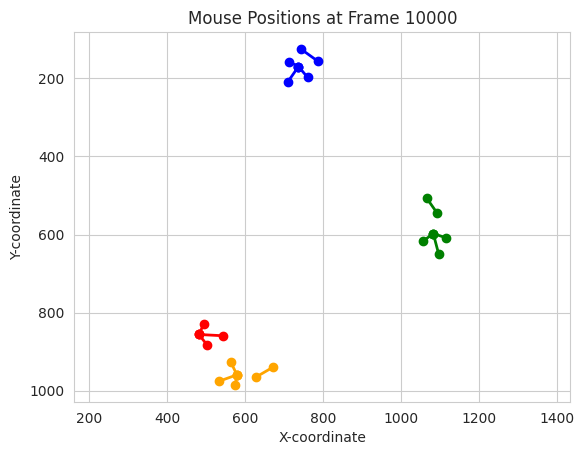

In [179]:
plot_frame(10000)

In [180]:
# 1. Pick a behavior to animate from our annotation sample
behavior_to_animate = sample_annotations.iloc[0]
start_frame = behavior_to_animate['start_frame']
stop_frame = behavior_to_animate['stop_frame']
action = behavior_to_animate['action']
agent = behavior_to_animate['agent_id']

print(f"Preparing to animate behavior: '{action}' by Mouse {agent}")
print(f"Frame range: {start_frame} to {stop_frame}")

Preparing to animate behavior: 'rear' by Mouse 2
Frame range: 4 to 139


In [181]:
# Add a small buffer before and after to see the context
ANIM_START = max(0, start_frame - 20)
ANIM_STOP = stop_frame + 20

# Slice our wide dataframe to get only the frames we need for the animation
anim_df = df_sample.loc[ANIM_START:ANIM_STOP]

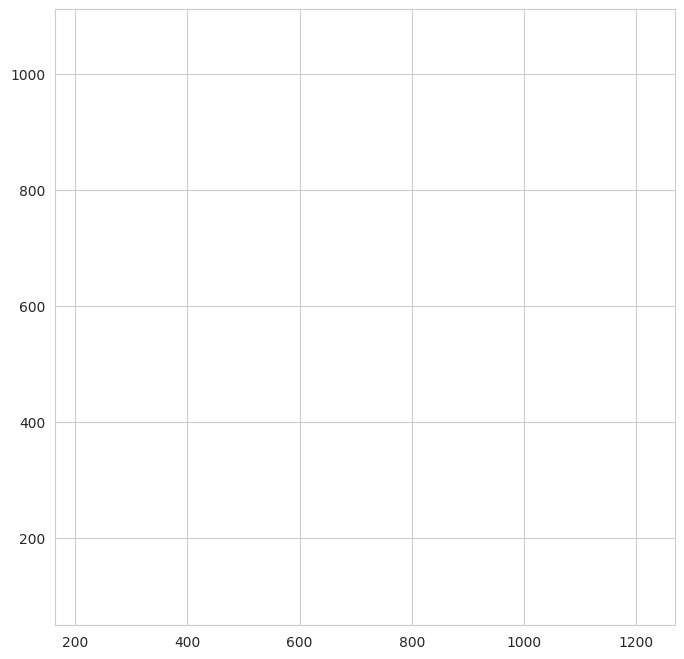

In [182]:
# --- Animation Setup ---

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(8, 8))

# Determine axis limits from the entire animation sequence to prevent jittering
x_min, x_max = anim_df.filter(like='_x').min().min(), anim_df.filter(like='_x').max().max()
y_min, y_max = anim_df.filter(like='_y').min().min(), anim_df.filter(like='_y').max().max()
padding = 50 # Add some padding to the plot
ax.set_xlim(x_min - padding, x_max + padding)
ax.set_ylim(y_min - padding, y_max + padding)


# The function that will draw each frame of the animation
def update(frame_num):
    ax.clear() # Clear the previous frame
    
    # Get the data for the current frame
    frame_data = anim_df.iloc[frame_num]
    current_real_frame = anim_df.index[frame_num]
    
    # Plot each mouse for the current frame
    for mouse_id in range(1, 5):
        if f'mouse_{mouse_id}_nose_x' not in frame_data or pd.isna(frame_data[f'mouse_{mouse_id}_nose_x']):
            continue

        # Plot keypoints
        for part in ANATOMICAL_BODYPARTS:
            col_x, col_y = f'mouse_{mouse_id}_{part}_x', f'mouse_{mouse_id}_{part}_y'
            if col_x in frame_data and col_y in frame_data:
                ax.scatter(frame_data[col_x], frame_data[col_y], color=MOUSE_COLORS[mouse_id])

        # Plot skeleton
        for part1, part2 in SKELETON_CONNECTIONS:
            col1_x, col1_y = f'mouse_{mouse_id}_{part1}_x', f'mouse_{mouse_id}_{part1}_y'
            col2_x, col2_y = f'mouse_{mouse_id}_{part2}_x', f'mouse_{mouse_id}_{part2}_y'
            if all(c in frame_data for c in [col1_x, col1_y, col2_x, col2_y]) and \
               pd.notna(frame_data[col1_x]) and pd.notna(frame_data[col2_x]):
                ax.plot([frame_data[col1_x], frame_data[col2_x]], [frame_data[col1_y], frame_data[col2_y]], color=MOUSE_COLORS[mouse_id], alpha=0.7)

    # Set titles and labels for the frame
    ax.set_title(f"Behavior: '{action}' by Mouse {agent} | Frame: {current_real_frame}")
    ax.set_xlabel("X-coordinate")
    ax.set_ylabel("Y-coordinate")
    ax.set_xlim(x_min - padding, x_max + padding)
    ax.set_ylim(y_min - padding, y_max + padding)
    ax.invert_yaxis() # Invert y-axis for image coordinates
    return ax,

In [183]:
# Create the animation
# frames=len(anim_df) specifies how many times to call the update function
# interval=50 is the delay between frames in milliseconds
ani = FuncAnimation(fig, update, frames=len(anim_df), interval=50, blit=False)

# Display the animation in the notebook
# This may take a little while to render
HTML(ani.to_jshtml())